#### Keras를 이용한 손글씨 인식

In [1]:
#  데이터 불러오기
import pandas as pd

train = pd.read_csv('../Data/train_20k.csv', header=None)
test = pd.read_csv('../Data/test_1k.csv', header=None)

In [2]:
train.head()
test.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# 결측치
train.info()
# 안보이는 이유: 데이터가 너무 많아서

<class 'pandas.DataFrame'>
RangeIndex: 20001 entries, 0 to 20000
Columns: 785 entries, 0 to 784
dtypes: int64(785)
memory usage: 119.8 MB


In [4]:
# 결측치_ 너무 많을때
train.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 20001 entries, 0 to 20000
Columns: 785 entries, 0 to 784
dtypes: int64(785)
memory usage: 119.8 MB


In [5]:
train.isnull().sum()

0      0
1      0
2      0
3      0
4      0
      ..
780    0
781    0
782    0
783    0
784    0
Length: 785, dtype: int64

In [6]:
train.sum()

0      89006
1          0
2          0
3          0
4          0
       ...  
780       62
781        0
782        0
783        0
784        0
Length: 785, dtype: int64

In [7]:
train.info(show_counts=True, max_cols=800)

<class 'pandas.DataFrame'>
RangeIndex: 20001 entries, 0 to 20000
Data columns (total 785 columns):
 #    Column  Non-Null Count  Dtype
---   ------  --------------  -----
 0    0       20001 non-null  int64
 1    1       20001 non-null  int64
 2    2       20001 non-null  int64
 3    3       20001 non-null  int64
 4    4       20001 non-null  int64
 5    5       20001 non-null  int64
 6    6       20001 non-null  int64
 7    7       20001 non-null  int64
 8    8       20001 non-null  int64
 9    9       20001 non-null  int64
 10   10      20001 non-null  int64
 11   11      20001 non-null  int64
 12   12      20001 non-null  int64
 13   13      20001 non-null  int64
 14   14      20001 non-null  int64
 15   15      20001 non-null  int64
 16   16      20001 non-null  int64
 17   17      20001 non-null  int64
 18   18      20001 non-null  int64
 19   19      20001 non-null  int64
 20   20      20001 non-null  int64
 21   21      20001 non-null  int64
 22   22      20001 non-null  int64
 

In [8]:
# train의 0번(Target)의 분포 확인
train[0].value_counts().sort_values(ascending=False)

0
1    2281
7    2093
3    2076
9    2014
0    1994
6    1971
4    1945
2    1929
8    1922
5    1776
Name: count, dtype: int64

#### Target(0), Feature(1~784) 분리하고 정규화 하기


In [9]:
train.iloc[:,1:784+1]

,1,2,3,4,5,6,7,8,9,10,...,775,776,777,778,779,780,781,782,783,784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19999,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
train_label = train.loc[:,train.columns == 0]
train_data  = train.loc[:,train.columns != 0]
train_data  = train_data / 255 # _ 정규화 해주려고

test_label = test.loc[:,test.columns == 0]
test_data  = test.loc[:,test.columns != 0]
test_data  = test_data / 255 # _ 정규화 해주려고

----
#### Deep Learning Model 만들기
- 입력층 : 784개
- 은닉층 : 1284개, activation = relu 
- 출력층 : 10개 , activation = softmax (분류)
- Compile : loss = (sparse_categorical_crossentropy), optimizer = adam
- epochs : 5,10, 50, 100

In [11]:
from tensorflow import keras
from tensorflow.keras.layers import Input
# 입력층 : 3 
# 은닉층 : 32
# 출력층 : 1
# activation : signoid, tanh ,relu,leakyRelu


model = keras.Sequential()
model.add(Input(shape=(784,)))
model.add(keras.layers.Dense(1284,activation='relu')) # 은닉층 : 2의 배수
model.add(keras.layers.Dense(10,activation='softmax'))




In [12]:
model.compile(
    optimizer= 'adam',
    loss ='sparse_categorical_crossentropy',
    metrics =['accuracy']
) # _ sparse_categorical_crossentropy : 다중분류 문제에서 사용되는 손실 함수

In [13]:
# 훈련 시키기 
import numpy as np
hist = model.fit(
        np.array(train_data),
        np.array(train_label),
        epochs = 50,
)

Epoch 1/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9134 - loss: 0.2860
Epoch 2/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9656 - loss: 0.1094
Epoch 3/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9808 - loss: 0.0635
Epoch 4/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9883 - loss: 0.0395
Epoch 5/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9921 - loss: 0.0281
Epoch 6/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9925 - loss: 0.0240
Epoch 7/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9944 - loss: 0.0169
Epoch 8/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9971 - loss: 0.0098
Epoch 9/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9943 - loss: 0.0178
Epoch 10/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9943 - loss: 0.0164
Epoch 11/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9981 - loss: 0.0057
Epoch 12/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

In [14]:
model.evaluate(np.array(train_data),np.array(train_label))

626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 2.1481e-06


[2.148069825125276e-06, 1.0]

In [15]:
model.evaluate(np.array(test_data),np.array(test_label))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9820 - loss: 0.1531 


[0.15311315655708313, 0.982017993927002]

In [16]:
# Train 데이터로 평가 
scores = model.evaluate(train_data, train_label)
print('loss : ', scores[0])
print('accuracy : ', scores[1])


626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 1.0000 - loss: 2.1481e-06
loss :  2.148069825125276e-06
accuracy :  1.0


In [17]:
# 테스트 데이터로 평가 
scores = model.evaluate(test_data, test_label) # np.array 안쓰는이유 -evaluate라서
print('loss : ', scores[0])
print('accuracy : ', scores[1])


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9820 - loss: 0.1531 
loss :  0.15311315655708313
accuracy :  0.982017993927002


In [18]:
# 훈련 및 과정 대한 history 보기
hist.history.keys()

dict_keys(['accuracy', 'loss'])

### 손실 곡선

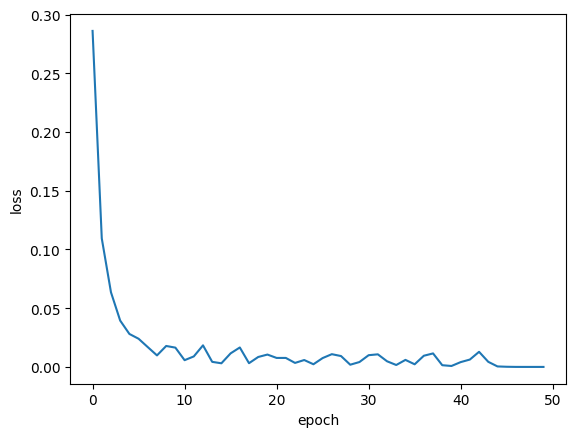

In [19]:
import matplotlib.pyplot as plt

plt.plot(hist.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

#### 정확도 곡선

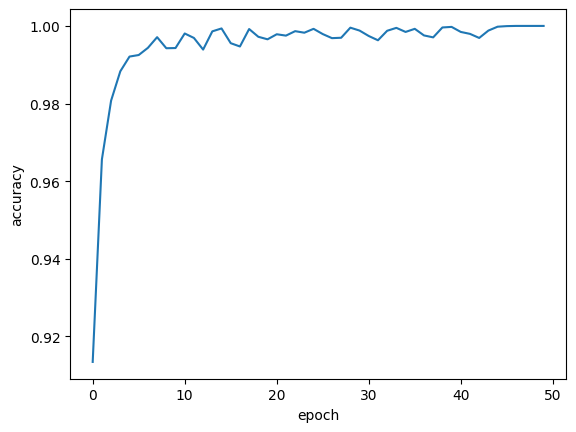

In [20]:
import matplotlib.pyplot as plt

plt.plot(hist.history['accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

---
#### test_data로 predict 해보기

In [21]:
pred = model.predict(test_data)
print('test_label :',test_label[:10])
print('pred :',np.argmax(pred[:10], axis=1))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
test_label :    0
0  7
1  2
2  1
3  0
4  4
5  1
6  4
7  9
8  5
9  9
pred : [7 2 1 0 4 1 4 9 5 9]


In [22]:
# np.ar

---
### 번외 : Image 만들기

In [23]:
from PIL import Image # _ 이미지 처리 라이브러리 : 포토샵 같은거 생각하면 됨

In [24]:
train.shape

(20001, 785)

In [25]:
train1 = train.loc[:, train.columns != 0]
train1.shape

(20001, 784)

In [26]:
abc = np.array(train1.iloc[50]).reshape(28,28)
abc.shape

(28, 28)

In [27]:
abc

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  12,  56, 140,
        126, 175, 200,  96,   2,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  35, 166, 238, 254, 246,
        242, 253, 246, 254,  67,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [28]:
# Image 만들기
image = Image.fromarray((abc).astype(np.uint8)) # _ uint8 : 0~255 사이의 정수로 표현하는 데이터 타입
image
# 배열에서 뽑아온 거

In [29]:
# image 저장하기
image.save('../Data/mnist_test_3.jpg',"JPEG")

-----
### 이미지를 불러서 Predict 해보기

In [30]:
# Image 불러오기
img = Image.open('../Data/mnist_test_3.jpg')
img

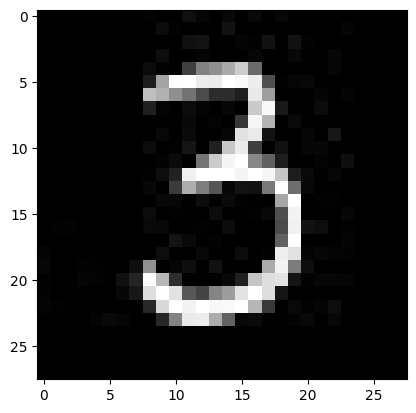

In [31]:
plt.imshow(img, cmap='gray')
plt.show()

In [32]:
# 이 이미지를 예측하려면 어레이로 바꾼뒤 , 프리딕트 해야 함

In [33]:
# image를 numpy 배열로 바꿔주기
imgArray = np.array(img)
imgArray = imgArray / 255
imgArray.shape

(28, 28)

In [34]:
# imgArray를 1차원 배열로 변경하기
imgArray2 = imgArray.reshape(-1) # _ -1 : 자동으로 계산해서 넣어줌 / -1을 넣은 이유 :
imgArray2.shape

(784,)

In [35]:
imgArray3 = imgArray2.tolist()
dfArray = pd.DataFrame(imgArray3)
dfArray = dfArray.T
dfArray

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.011765,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [36]:
np.argmax(model.predict(dfArray),axis=1) # 안되는 이유 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


array([3])